In [1]:
from torchsummary import summary
import reinforcement
import models
import networks
import gymnasium as gym
import numpy as np
import torch
import ale_py
import time
import utils

In [ ]:
env = gym.make("BipedalWalker-v3", hardcore = 1)
s, _ = env.reset()

env.states = env.observation_space.shape[0]
env.actions = env.action_space.shape[0]

actor = models.MLP(env.states, env.actions, softmax=False, tanh=True, lr = 1e-5, hidden_dims = [400, 300, 200])
critic = models.MLP((env.states+env.actions), 1, softmax=False, lr = 1e-4, hidden_dims = [400, 300, 200])

#actor.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/1000ep_solve/models/actor_ep1000.pth"))
#critic.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/1000ep_solve/models/critic_ep1000.pth"))

device = "cuda"
actor.to(device)
critic.to(device)

rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, gamma = 0.95, episodes = 1000, verbose=1, checkpoint=50)
#rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, episodes = 100, verbose=1, checkpoint=999, BATCH_SIZE=0)


c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 0 finished with reward -100.44132995605469 in 86 steps and 0.024515 time, Total steps: 87
Actor loss: 0, Critic loss: 0, Total steps: 87
Episode 1 finished with reward -102.79545593261719 in 83 steps and 0.025775 time, Total steps: 171
Actor loss: 0, Critic loss: 0, Total steps: 171
Episode 2 finished with reward -138.9307098388672 in 1593 steps and 8.532256 time, Total steps: 1765
Actor loss: 0.12792266694938434, Critic loss: 0.02206727855723181, Total steps: 1765
Episode 3 finished with reward -138.21539306640625 in 166 steps and 1.917723 time, Total steps: 1932
Actor loss: 0.16907944953805226, Critic loss: 57.0510173986058, Total steps: 1932
Episode 4 finished with reward -115.32154846191406 in 33 steps and 0.371932 time, Total steps: 1966
Actor loss: 1.031054114594179, Critic loss: 58.62594503514907, Total steps: 1966
Episode 5 finished with reward -128.11309814453125 in 97 steps and 1.058249 time, Total steps: 2064
Actor loss: 2.0888734871939736, Critic loss: 34.5928240990

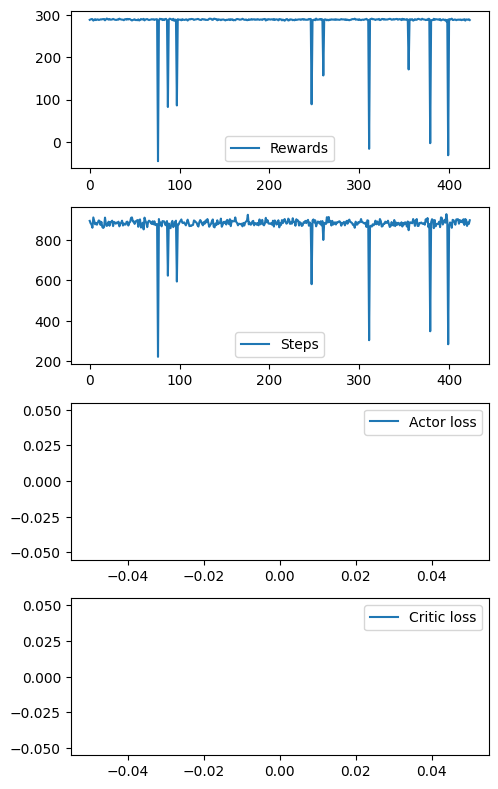

In [ ]:
import matplotlib.pyplot as plt
## Plot the rewards, steps, and errors
fig, ax = plt.subplots(4, figsize=(5, 8))
ax[0].plot(rewards, label='Rewards')
ax[1].plot(steps, label='Steps')
ax[2].plot(actor_loss, label='Actor loss')  
ax[3].plot(critic_loss, label='Critic loss')  

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

print(np.mean(rewards), np.mean(steps))

plt.tight_layout()
plt.show()

In [ ]:


env = gym.make("BipedalWalker-v3", hardcore = 1, render_mode = "rgb_array")

#video_folder = "agents/ddpg/BipedalWalker-v3/2025-06-24_16;52;53/videos"
video_folder = "temp/"
utils.record_model(env, actor, video_folder, "ep1000")

Episode finished. Total reward: -22.521469116210938
